In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.head()

,Weekly_Sales,IsHoliday
Date,,
2010-02-05,49750740.50,False
2010-02-12,48336677.63,True
2010-02-19,48276993.78,False
2010-02-26,43968571.13,False
2010-03-05,46871470.30,False


['IsHoliday', 'lag1', 'lag5', 'month', 'week', 'moving_avg',
       'moving_median', 'moving_std', 'moving_max', 'moving_sum']

In [3]:
df['lag1'] = df['Weekly_Sales'].shift(1)
df['lag5'] = df['Weekly_Sales'].shift(5)
df['month'] = df.index.month
df['week'] = (df.index.day - 1) // 7 + 1
df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()
df.head()


,Weekly_Sales,IsHoliday,lag1,lag5,month,week,moving_avg,moving_median,moving_std,moving_max,moving_sum
Date,,,,,,,,,,,
2010-02-05,49750740.50,False,NaN,NaN,2,1,NaN,NaN,NaN,NaN,NaN
2010-02-12,48336677.63,True,49750740.50,NaN,2,2,NaN,NaN,NaN,NaN,NaN
2010-02-19,48276993.78,False,48336677.63,NaN,2,3,NaN,NaN,NaN,NaN,NaN
2010-02-26,43968571.13,False,48276993.78,NaN,2,4,47583245.76,4.830684e+07,2.504187e+06,49750740.50,1.903330e+08
2010-03-05,46871470.30,False,43968571.13,NaN,3,1,46863428.21,4.757423e+07,2.045230e+06,48336677.63,1.874537e+08


In [4]:
import joblib

xgb = joblib.load('xgb_model.pkl')
x = df.drop('Weekly_Sales',axis=1)
y = df['Weekly_Sales']
actual = y[-12:]

to_pred_on = x[-12:]
y_pred = xgb.predict(to_pred_on)

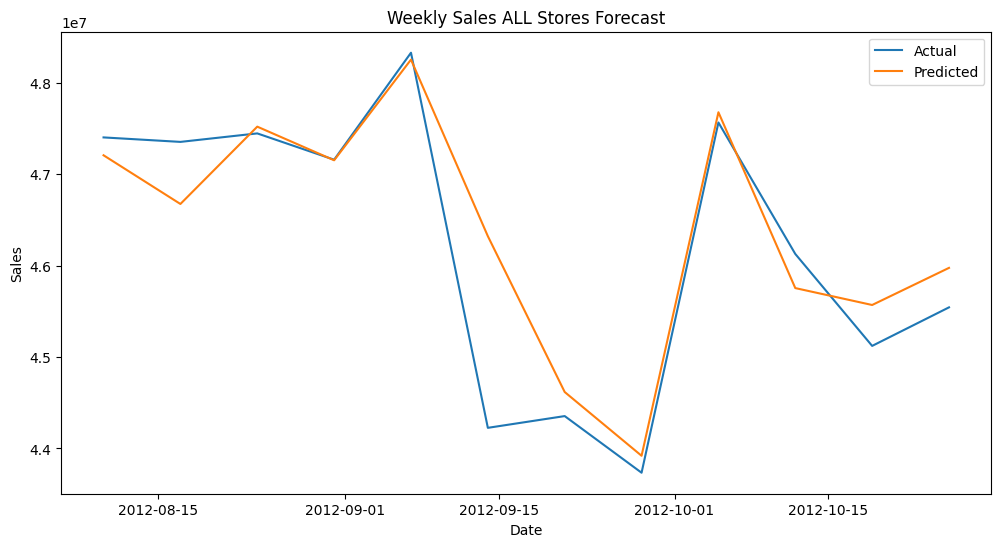

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(actual.index, actual, label='Actual')
plt.plot(actual.index,y_pred, label='Predicted')
plt.title('Weekly Sales ALL Stores Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [6]:
data = pd.DataFrame({
    'Weekly_Sales_Predicted': y_pred,
    'Weekly_Sales_Actual': actual
})

In [7]:
data.shape

(12, 2)

prediction on seen data 

In [8]:
data.tail()

,Weekly_Sales_Predicted,Weekly_Sales_Actual
Date,,
2012-09-28,43920416.0,43734899.40
2012-10-05,47678652.0,47566639.31
2012-10-12,45755040.0,46128514.25
2012-10-19,45570024.0,45122410.57
2012-10-26,45976128.0,45544116.29


In [9]:
df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

In [10]:
print(df1['Date'].tail(1))
print(df2['Date'].head(1))

421569    2012-10-26
Name: Date, dtype: object
0    2012-11-02
Name: Date, dtype: object


In [11]:
df = pd.concat([df1, df2], axis=0)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.head()

,Weekly_Sales,IsHoliday
Date,,
2010-02-05,49750740.50,False
2010-02-12,48336677.63,True
2010-02-19,48276993.78,False
2010-02-26,43968571.13,False
2010-03-05,46871470.30,False


In [12]:
df['lag1'] = df['Weekly_Sales'].shift(1)
df['lag5'] = df['Weekly_Sales'].shift(5)
df['month'] = df.index.month
df['week'] = (df.index.day - 1) // 7 + 1
df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()

In [13]:
df[:'2012-11-02'].tail(6)    

,Weekly_Sales,IsHoliday,lag1,lag5,month,week,moving_avg,moving_median,moving_std,moving_max,moving_sum
Date,,,,,,,,,,,
2012-09-28,43734899.40,False,44354547.11,47447323.60,9,4,4.516139e+07,44290292.88,2.129258e+06,48330059.31,1.806455e+08
2012-10-05,47566639.31,False,43734899.40,47159639.43,10,1,4.497053e+07,44290292.88,1.751216e+06,47566639.31,1.798821e+08
2012-10-12,46128514.25,False,47566639.31,48330059.31,10,2,4.544615e+07,45241530.68,1.739930e+06,47566639.31,1.817846e+08
2012-10-19,45122410.57,False,46128514.25,44226038.65,10,3,4.563812e+07,45625462.41,1.617393e+06,47566639.31,1.825525e+08
2012-10-26,45544116.29,False,45122410.57,44354547.11,10,4,4.609042e+07,45836315.27,1.067109e+06,47566639.31,1.843617e+08
2012-11-02,0.00,False,45544116.29,43734899.40,11,1,3.419876e+07,45333263.43,2.280291e+07,46128514.25,1.367950e+08


In [14]:
df['2012-11-02':].head(6)

,Weekly_Sales,IsHoliday,lag1,lag5,month,week,moving_avg,moving_median,moving_std,moving_max,moving_sum
Date,,,,,,,,,,,
2012-11-02,0.0,False,45544116.29,43734899.40,11,1,3.419876e+07,4.533326e+07,2.280291e+07,46128514.25,1.367950e+08
2012-11-09,0.0,False,0.00,47566639.31,11,2,2.266663e+07,2.256121e+07,2.617374e+07,45544116.29,9.066653e+07
2012-11-16,0.0,False,0.00,46128514.25,11,3,1.138603e+07,0.000000e+00,2.277206e+07,45544116.29,4.554412e+07
2012-11-23,0.0,True,0.00,45122410.57,11,4,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00
2012-11-30,0.0,False,0.00,45544116.29,11,5,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00
2012-12-07,0.0,False,0.00,0.00,12,1,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00


In [15]:
features = ['IsHoliday','lag1', 'lag5', 'month', 'week', 'moving_avg', 'moving_median', 'moving_std', 'moving_max', 'moving_sum']
forecast_dates = df.index[df.index >= '2012-11-02']
for date in forecast_dates:
    X_current = df.loc[[date], features]

    df.loc[date, 'Weekly_Sales'] = xgb.predict(X_current)[0]
    # Recalculate rolling features based on the new prediction # month and week are already calculated
    df['lag1'] = df['Weekly_Sales'].shift(1)
    df['lag5'] = df['Weekly_Sales'].shift(5)
    df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
    df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
    df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
    df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
    df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()

In [16]:
prediction_on_future_dates = df['2012-11-02':]['Weekly_Sales']

In [17]:
prediction =pd.DataFrame(prediction_on_future_dates)

In [18]:
prediction.head()

,Weekly_Sales
Date,
2012-11-02,53361484.0
2012-11-09,49376804.0
2012-11-16,53842944.0
2012-11-23,56055952.0
2012-11-30,57404076.0


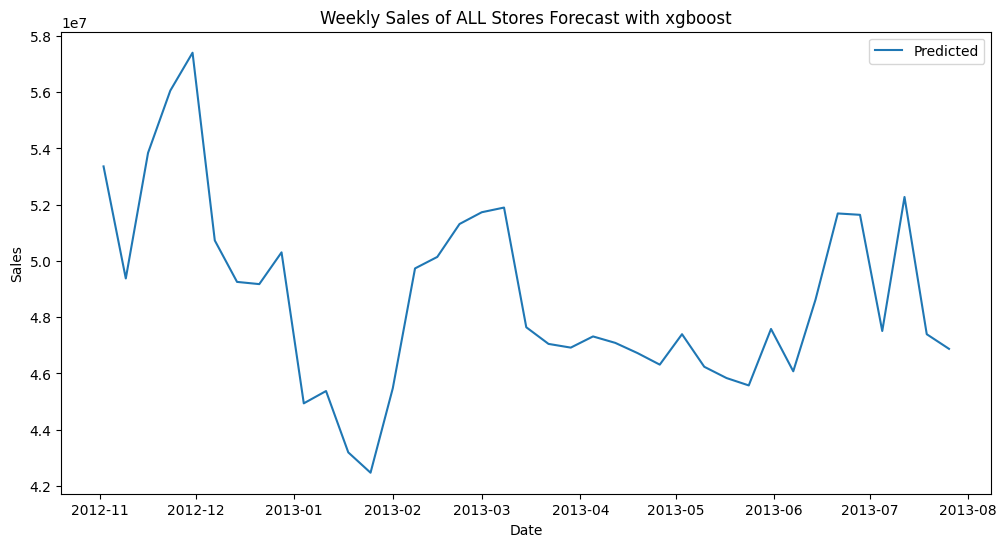

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(prediction.index, prediction['Weekly_Sales'], label='Predicted')
plt.title('Weekly Sales of ALL Stores Forecast with xgboost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [20]:
prediction.to_csv('prediction.csv')
data.to_csv('data.csv')